# Dataset creation (raw CSVs -> MongoDB)

End-to-end pipeline that:
1. Discovers raw `acc`/`gyr` CSVs under `data/`.
2. Pairs them by session key, merges on `Epoch` and applies a zero-phase Butterworth lowpass
3. Saves a static 6-axis time-series plot and a 3D acc/gyr scatter per session under `outputs/figures/`.
4. Filters with lowpass Butterworth
4. Inserts one merged document per session into the MongoDB collection from `config.yml`.

All heavy lifting lives in `utils.py` and `utils_visual.py` - this notebook is just orchestration.

> **Prerequisite:** MongoDB is running locally (`mongod` service up). On macOS: `brew services start mongodb-community`. On Windows: `net start MongoDB`. on Linux terminal to start MongoDB shel use the `mongosh`


## Setup

In [1]:
import os
from pathlib import Path
from collections import Counter

import yaml
from pathlib import Path

from utils import (
    discover_csvs, pair_acc_gyr, build_document,
    load_acc_csv, load_gyr_csv, merge_acc_gyr, apply_continuous_filter,
    mongo_connect, insert_documents
)
from utils_visual import load_data_for_visualization, Plot_3axis, Plot_6axis

## Load configuration

In [3]:
BASE_DIR = Path(os.getcwd()).resolve()

config_path = BASE_DIR / "config.yml"
with open(config_path, encoding='utf-8') as f:
    config = yaml.safe_load(f)
DATA_DIR = (BASE_DIR / config["data_path"]).resolve()
FIGURES_DIR = (BASE_DIR / config["out_figures"]).resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILTER_ORDER = config["filter"]["order"]
FILTER_WN = config["filter"]["wn"]
FILTER_TYPE = config["filter"]["type"]

print("data:    ", DATA_DIR)
print("figures: ", FIGURES_DIR)
print(f"filter:   Butterworth {FILTER_TYPE} order={FILTER_ORDER} wn={FILTER_WN}")

data:     /home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/data
figures:  /home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/outputs/figures
filter:   Butterworth lowpass order=4 wn=0.2


## 1. Discover + Pair raw CSVs

Each session has **two** raw CSVs (`acc` + `gyr` separately). We pair them by their shared key `(gesture_id, finger, typing_style, hand, primary, user)` - the only field that differs is `sensor`.

In [4]:
csvs = discover_csvs(DATA_DIR)
print(f"Found {len(csvs)} CSV files")

pairs = list(pair_acc_gyr(csvs))
print(f"Paired {len(pairs)} sessions (expecting 27 = 9 gesture×variant × 3 users)")

# Quick sanity: balance per (gesture, user)
Counter((m["gesture_id"], m["user"]) for m, _, _ in pairs)

Found 54 CSV files
Paired 27 sessions (expecting 27 = 9 gesture×variant × 3 users)


Counter({('scroll-down', 'a'): 2,
         ('scroll-down', 'b'): 2,
         ('scroll-down', 's'): 2,
         ('scroll-up', 'a'): 2,
         ('scroll-up', 'b'): 2,
         ('scroll-up', 's'): 2,
         ('swipe-left', 'a'): 2,
         ('swipe-left', 'b'): 2,
         ('swipe-left', 's'): 2,
         ('swipe-right', 'a'): 2,
         ('swipe-right', 'b'): 2,
         ('swipe-right', 's'): 2,
         ('texting', 'a'): 1,
         ('texting', 'b'): 1,
         ('texting', 's'): 1})

## 2. Visualize Data from Wearable

Each gesture includes the thumb and index, with either finger including the accelerometer and gyroscope graphs in sample domain of 128 first samples of the unfiltered raw data. 

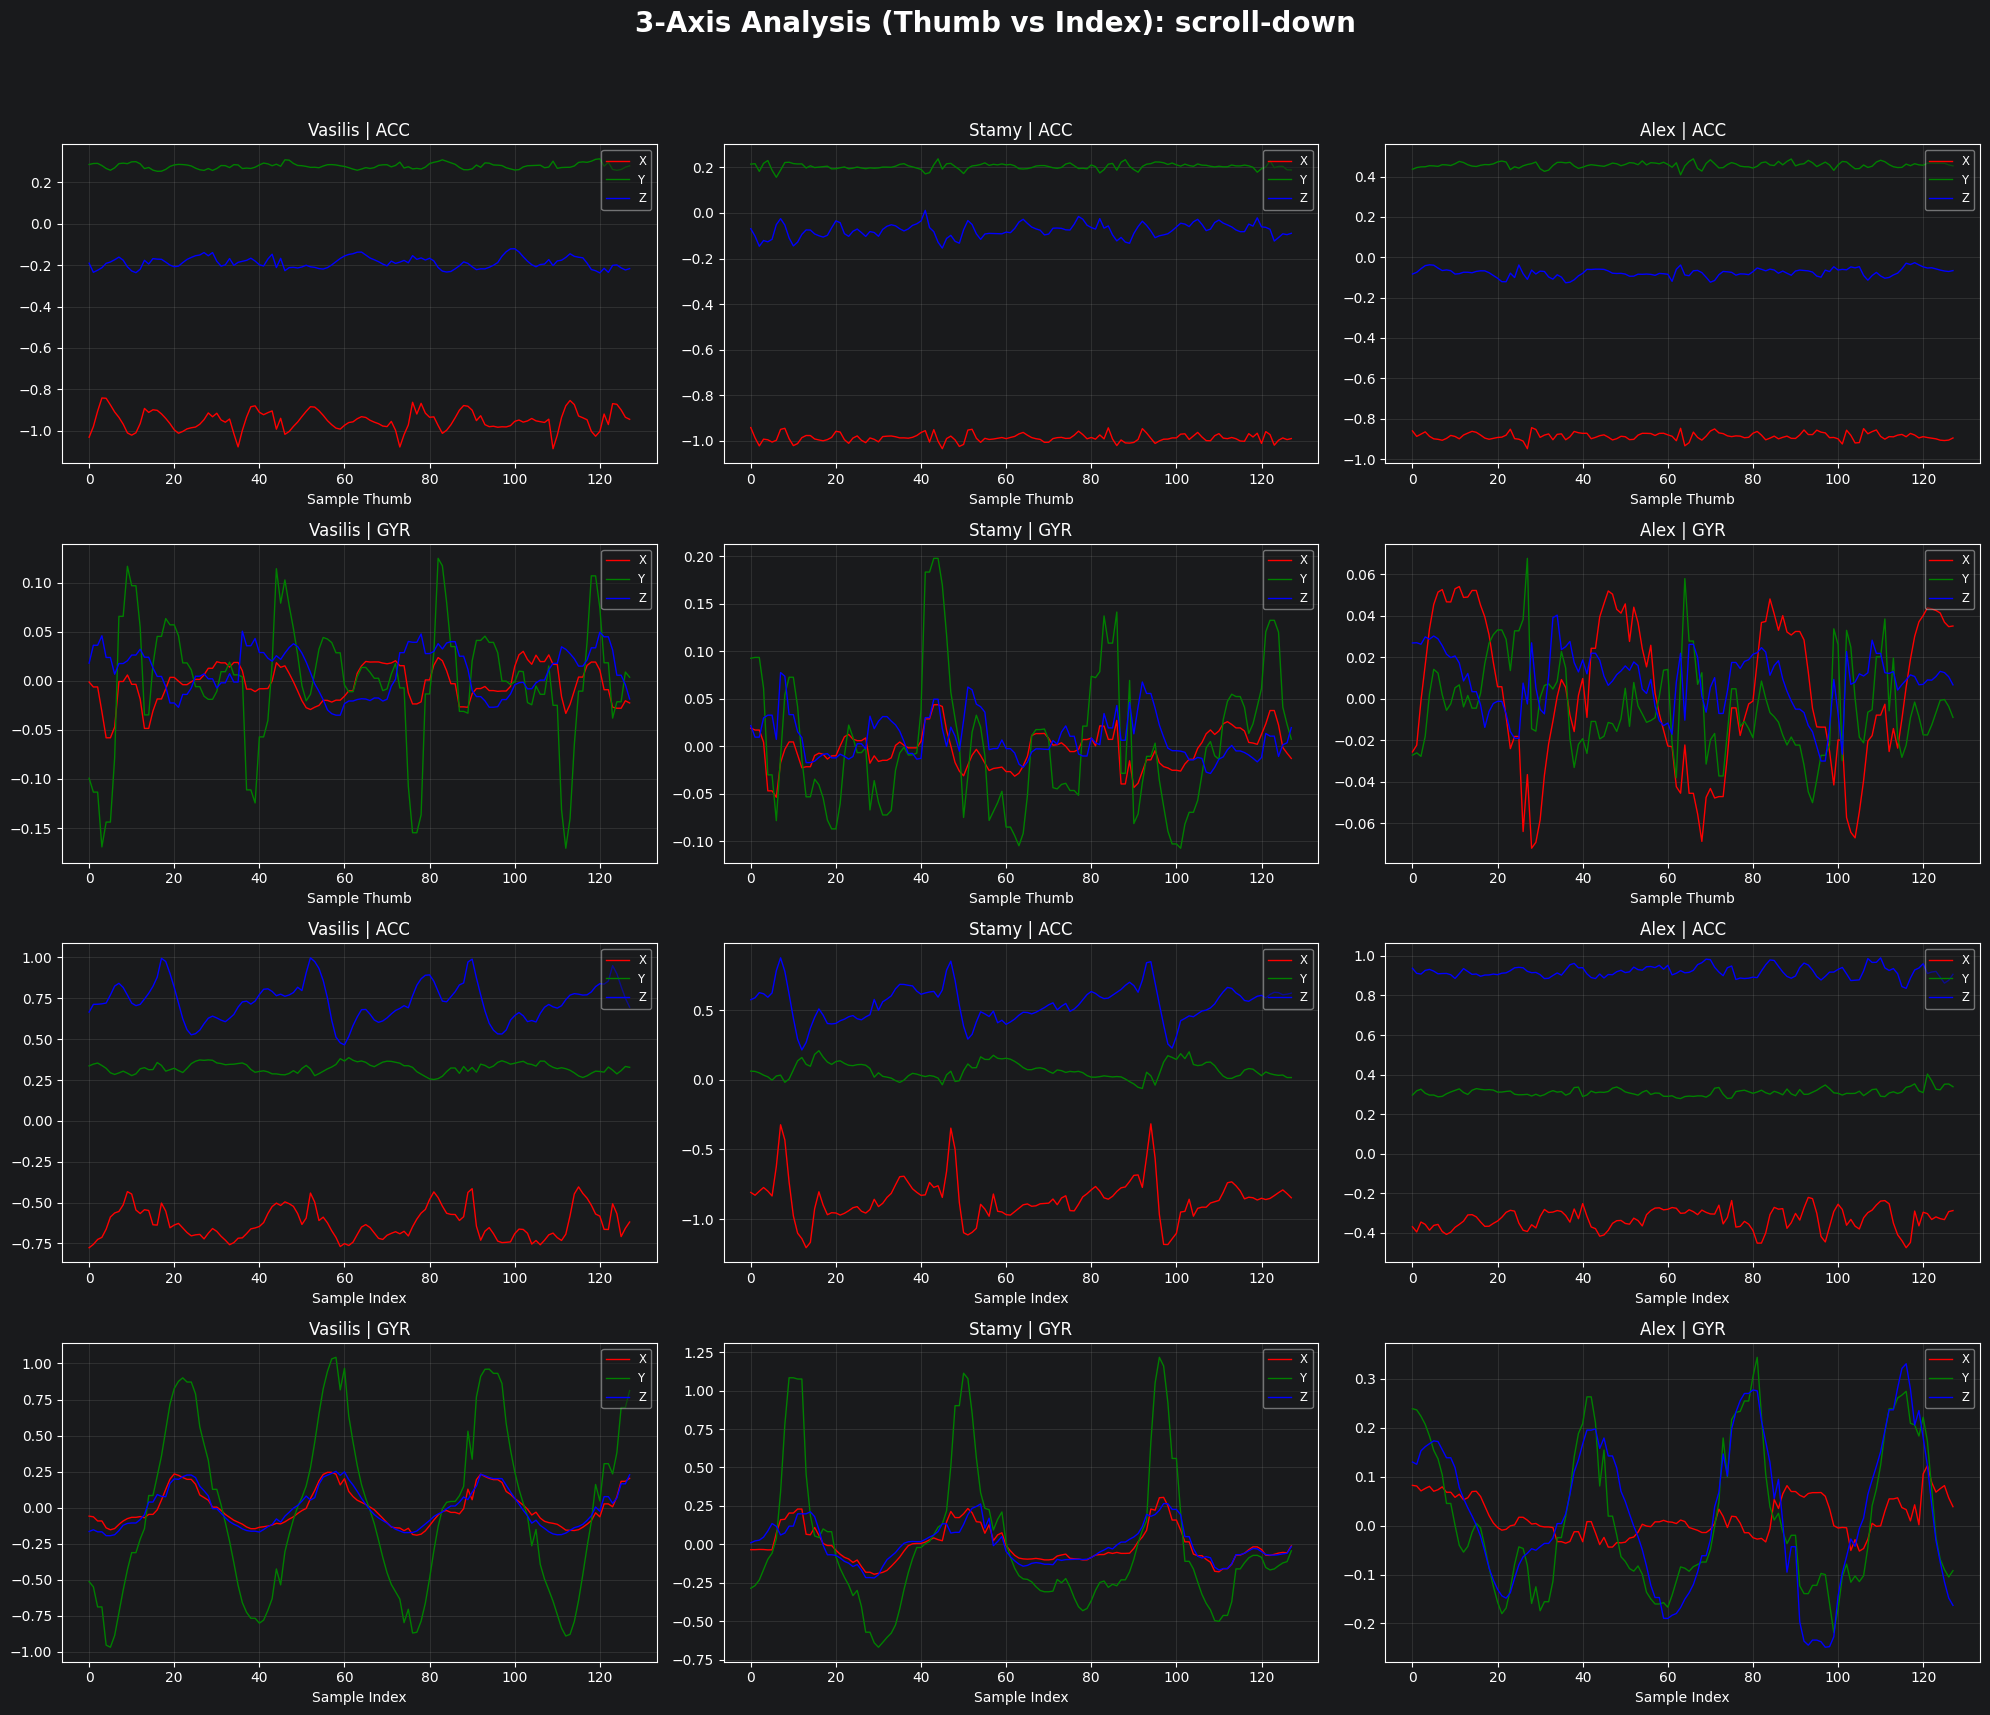

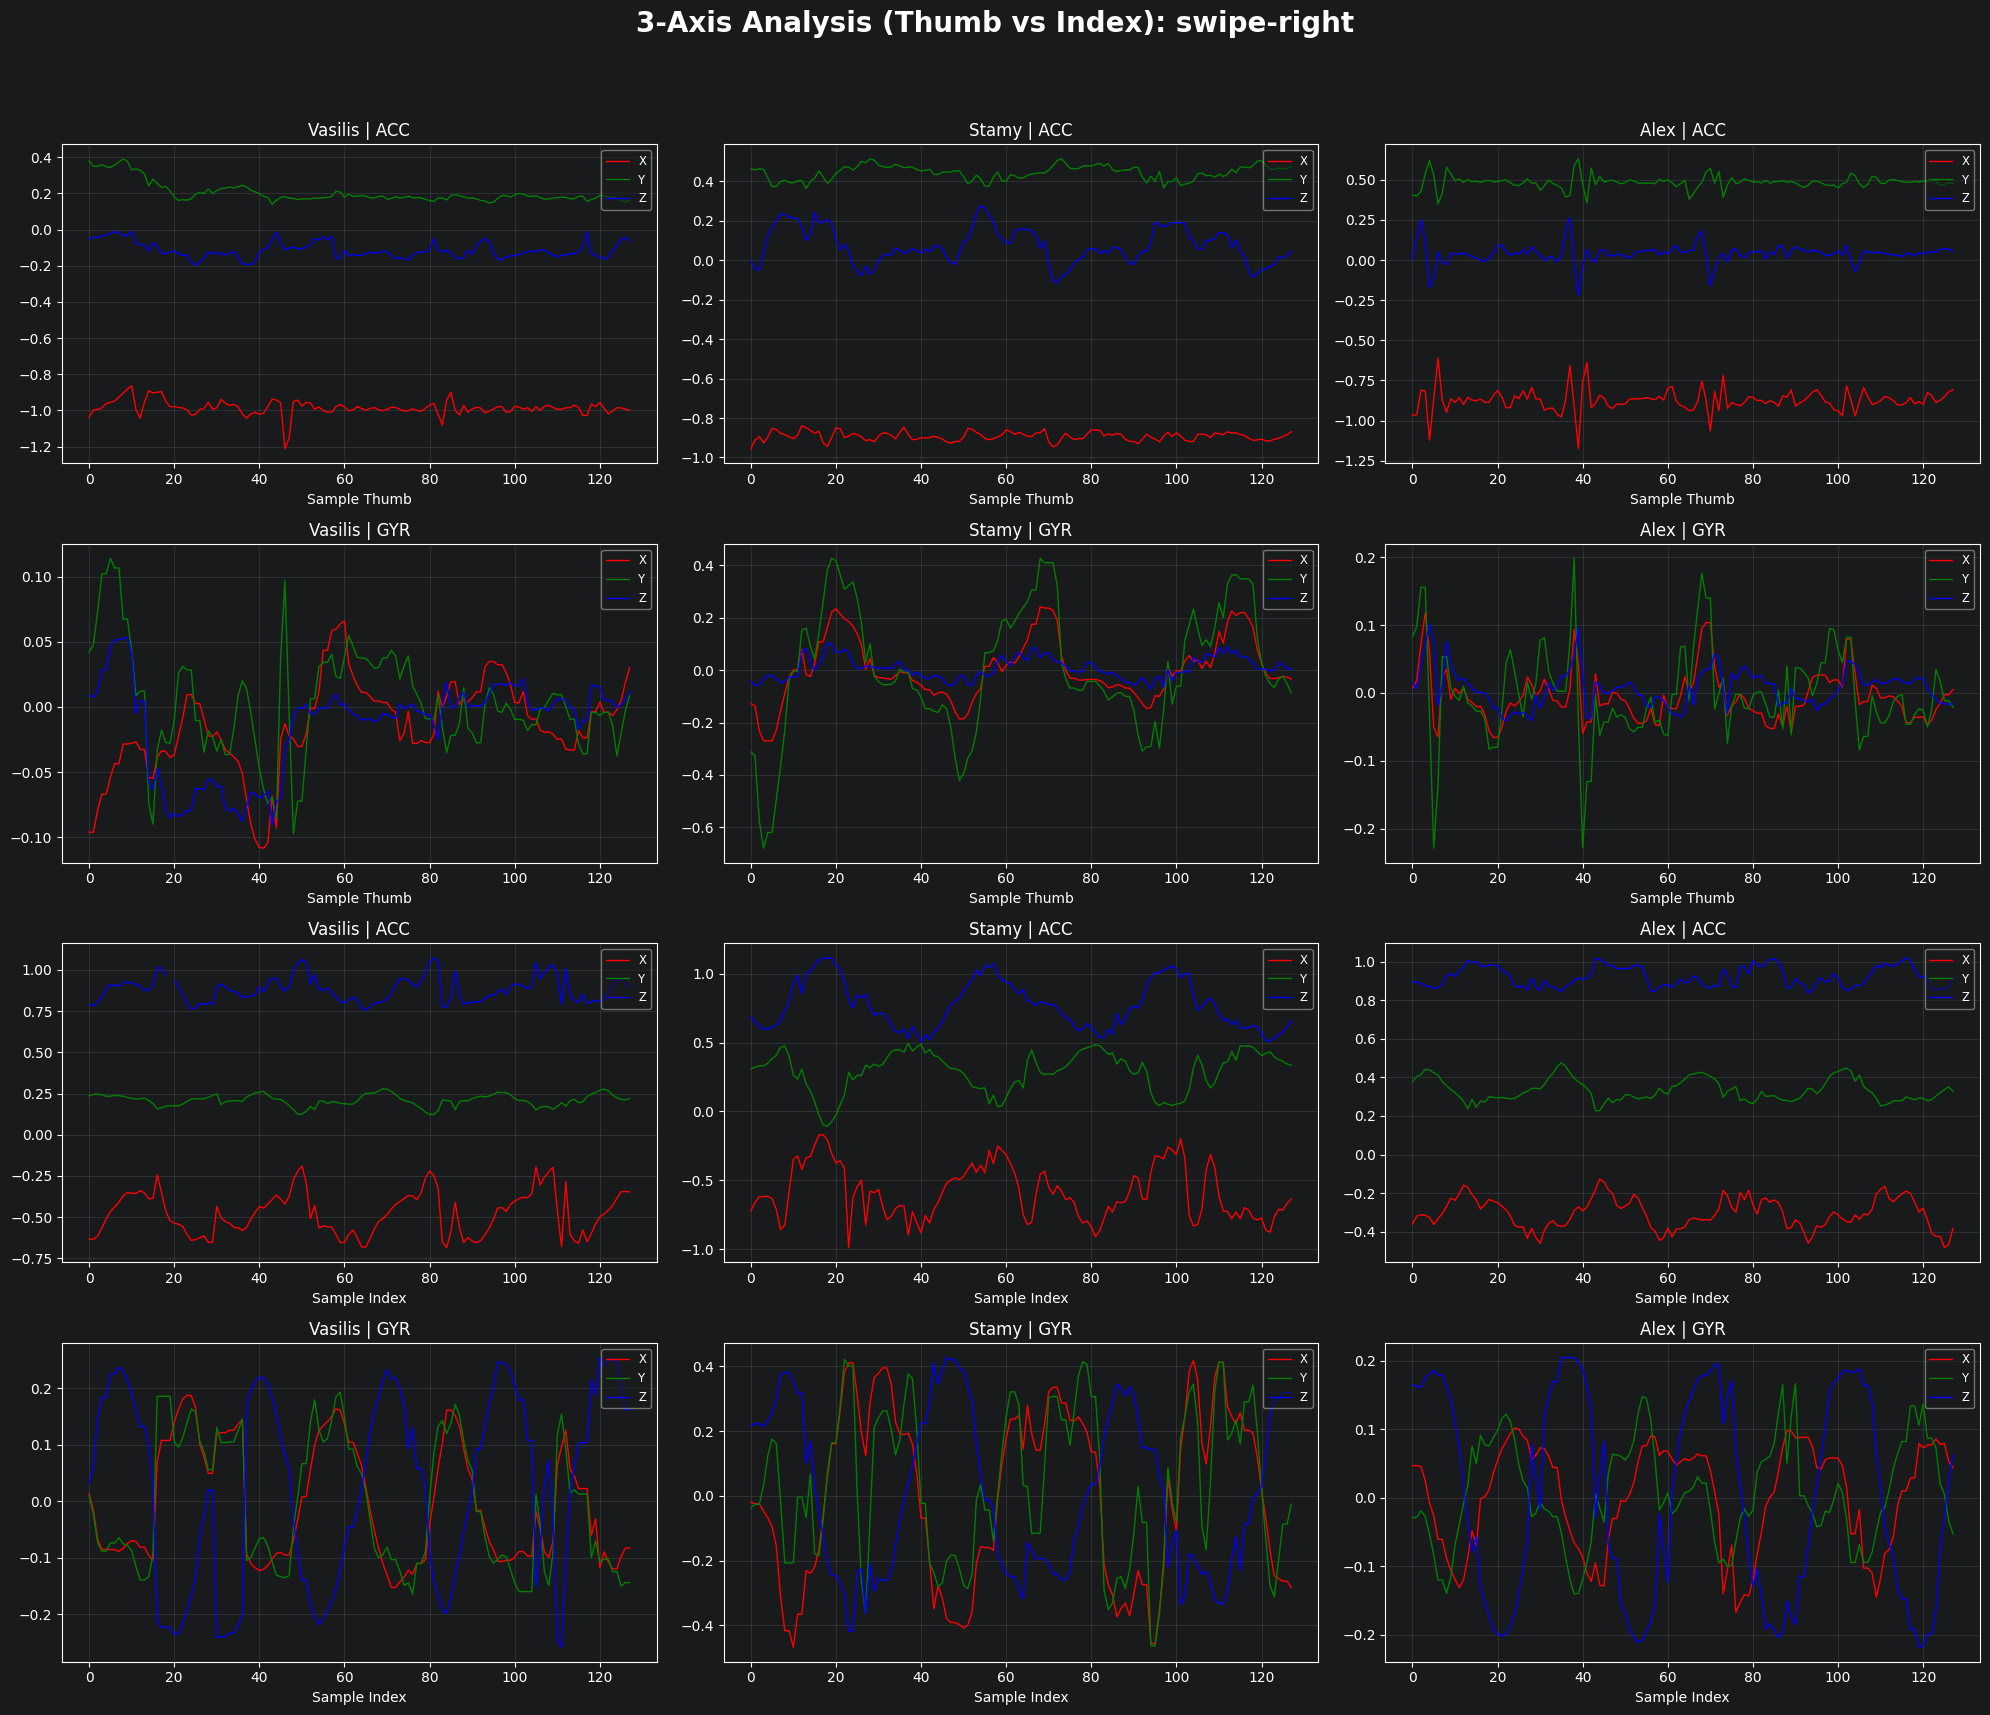

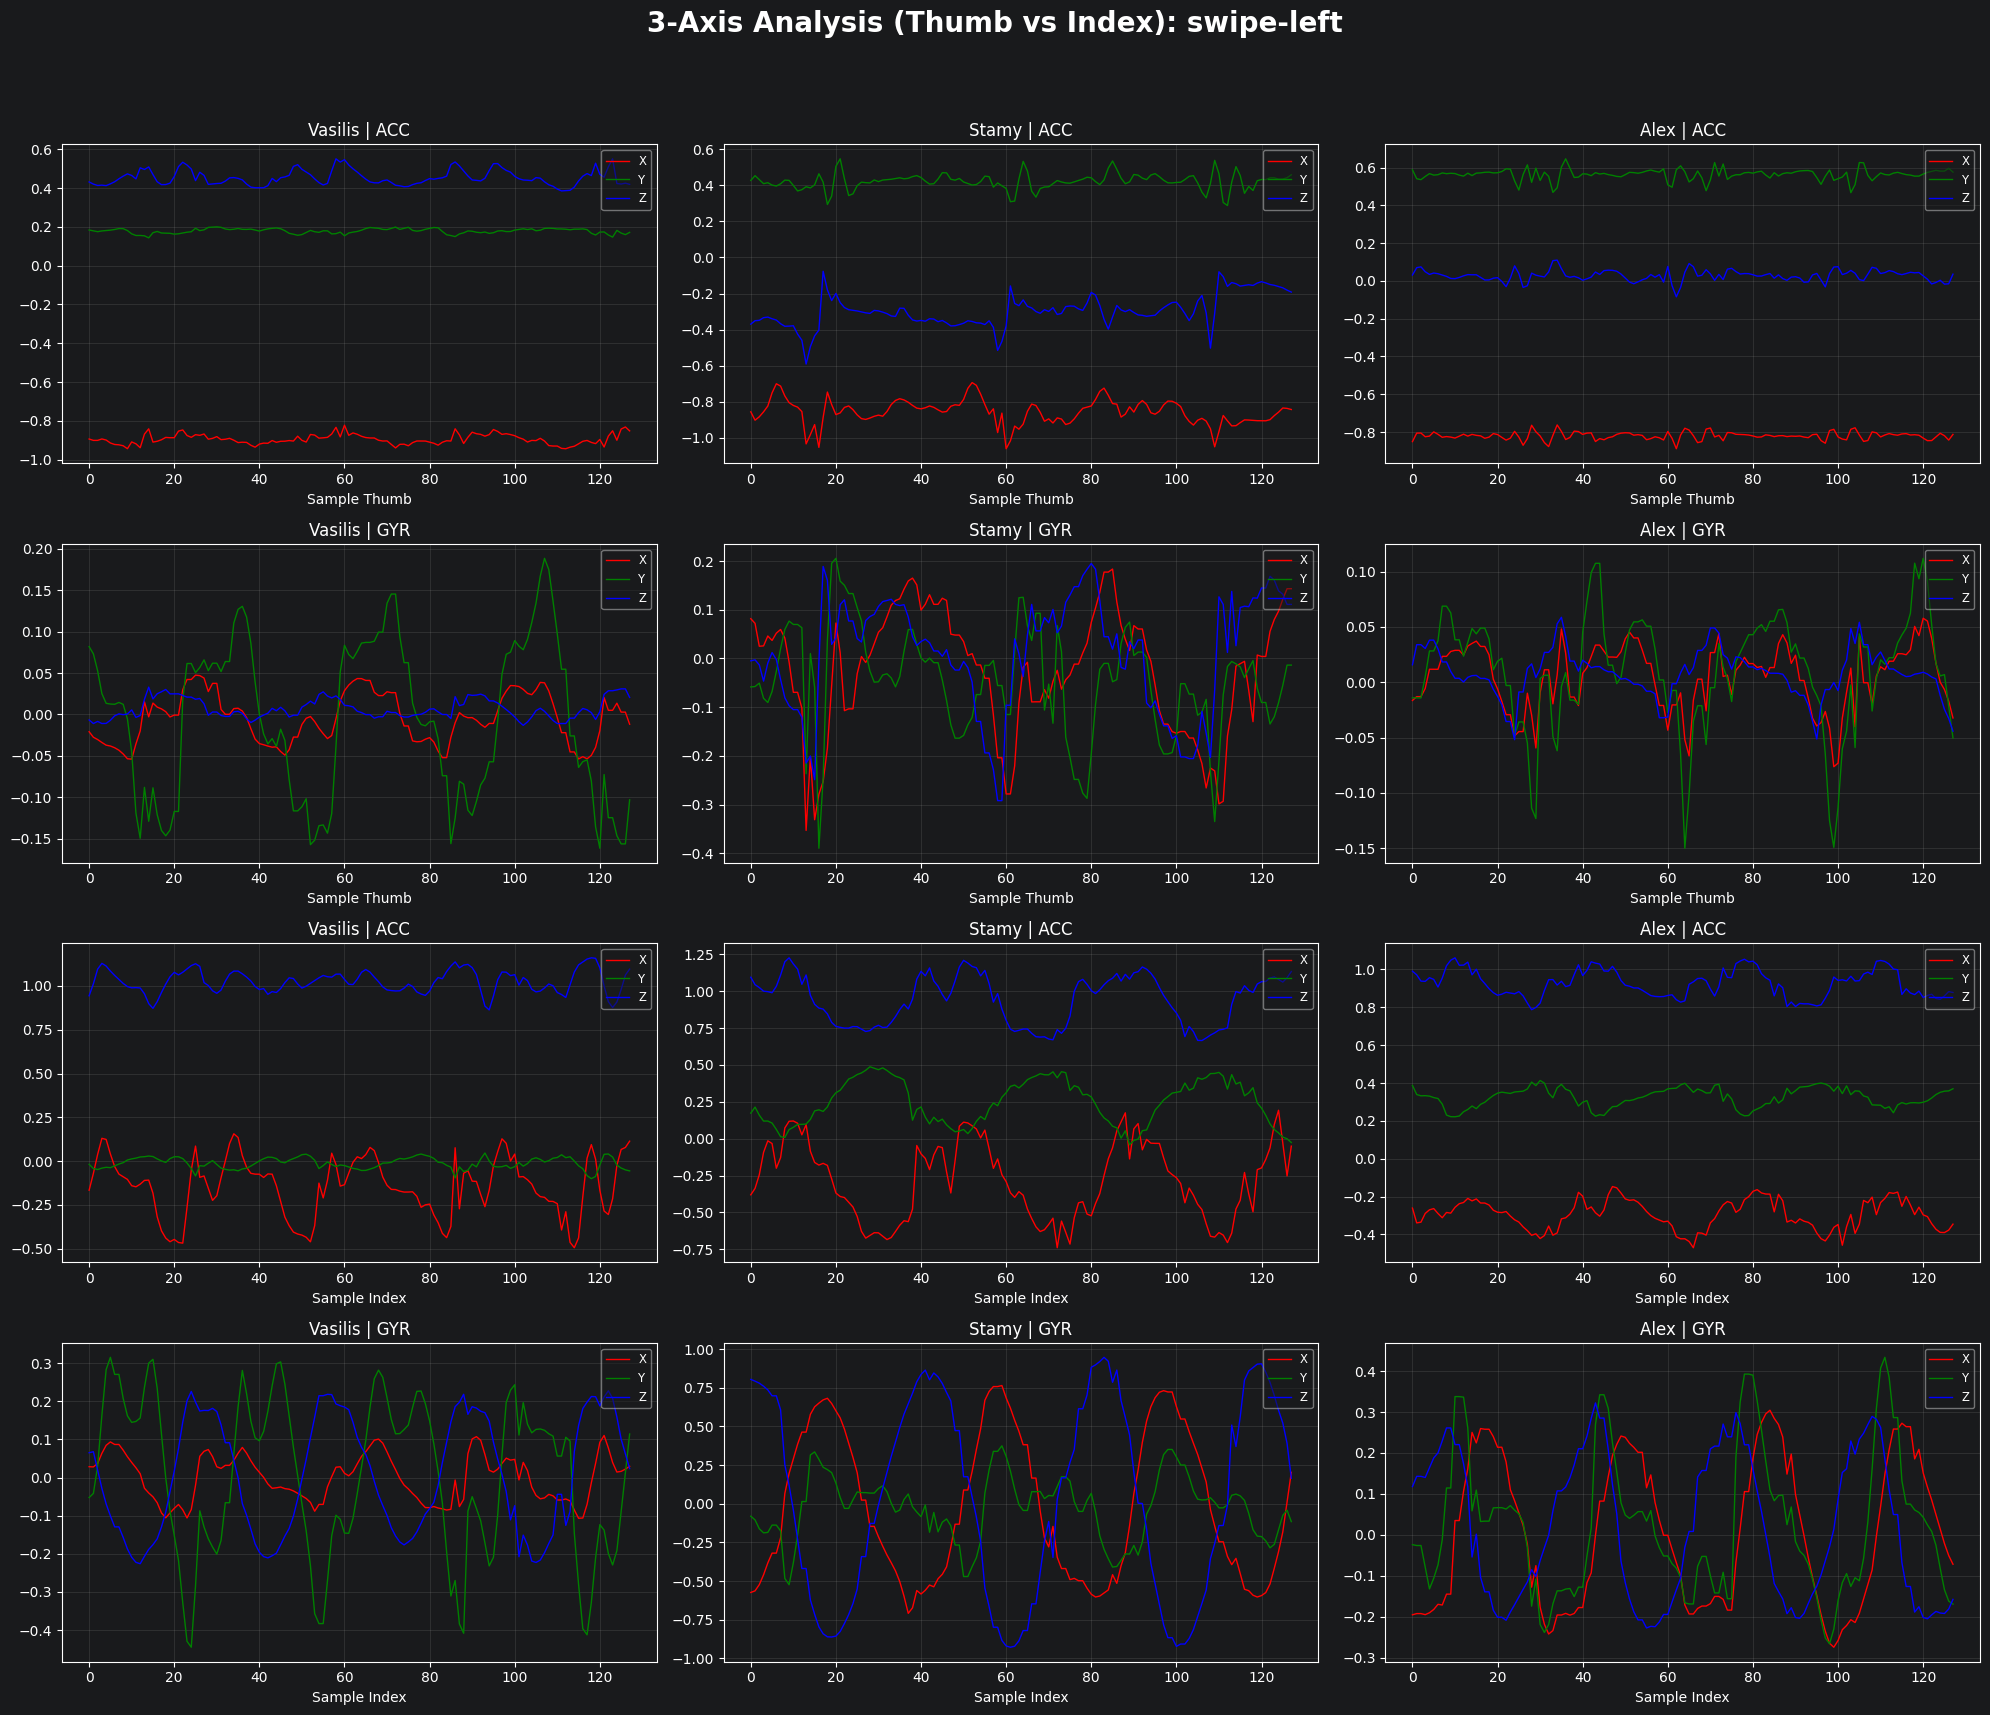

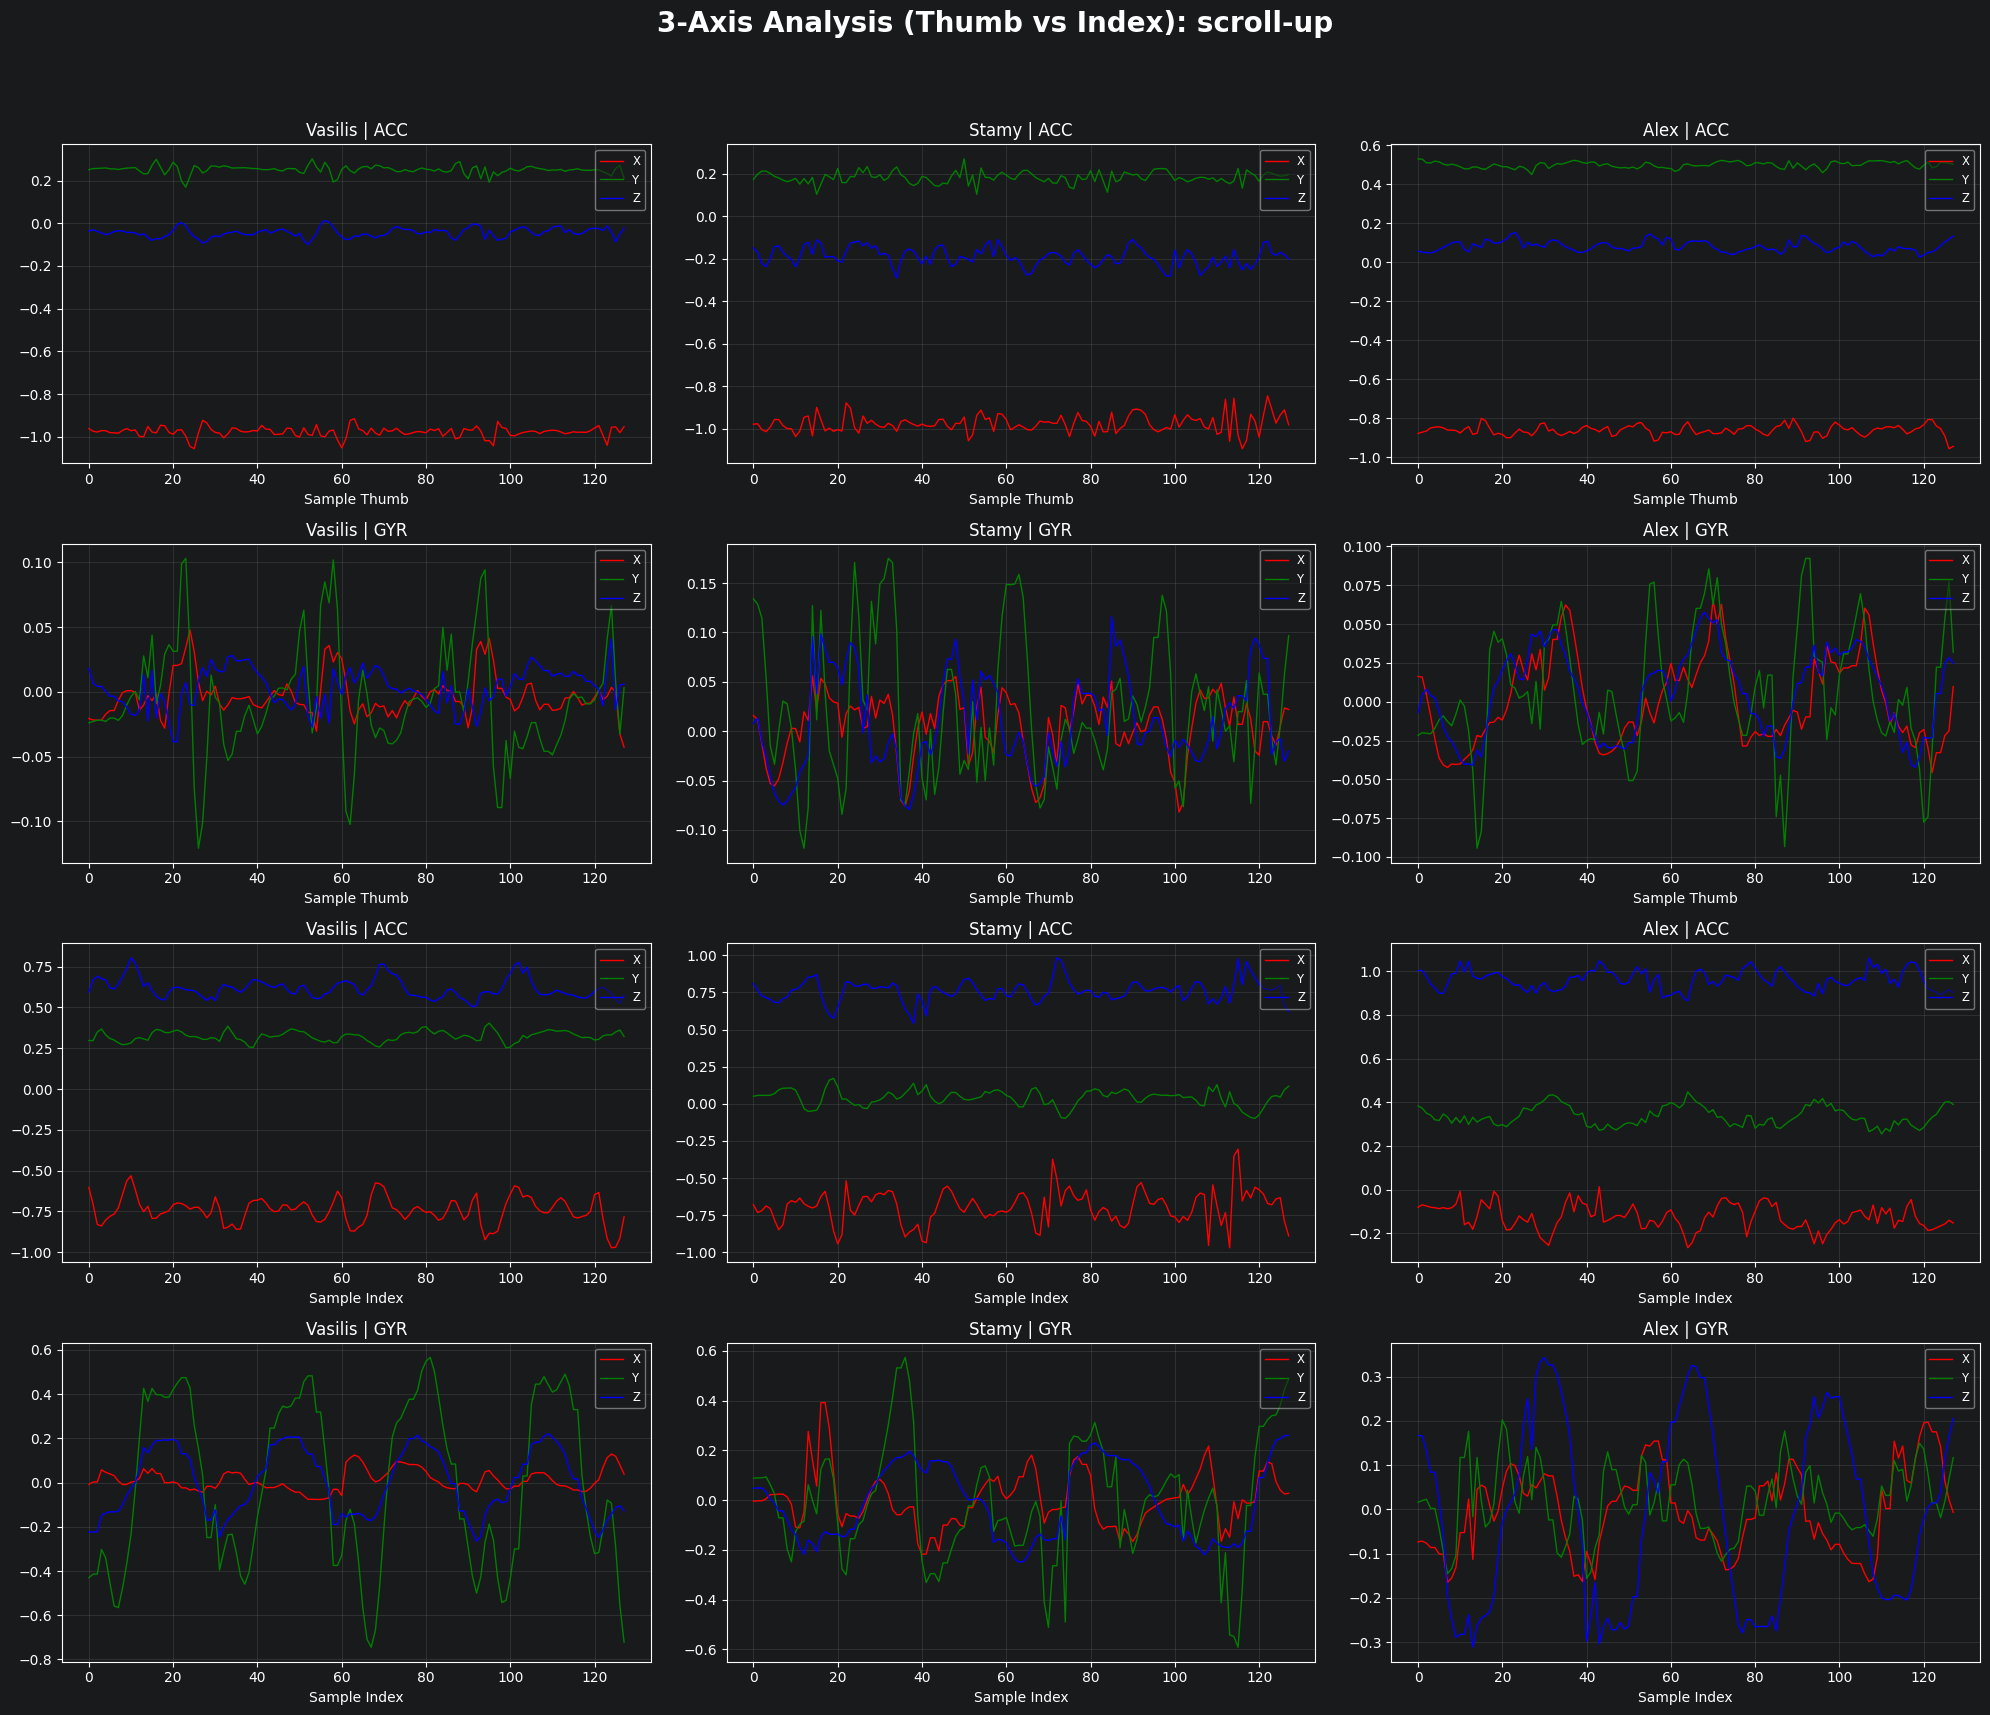

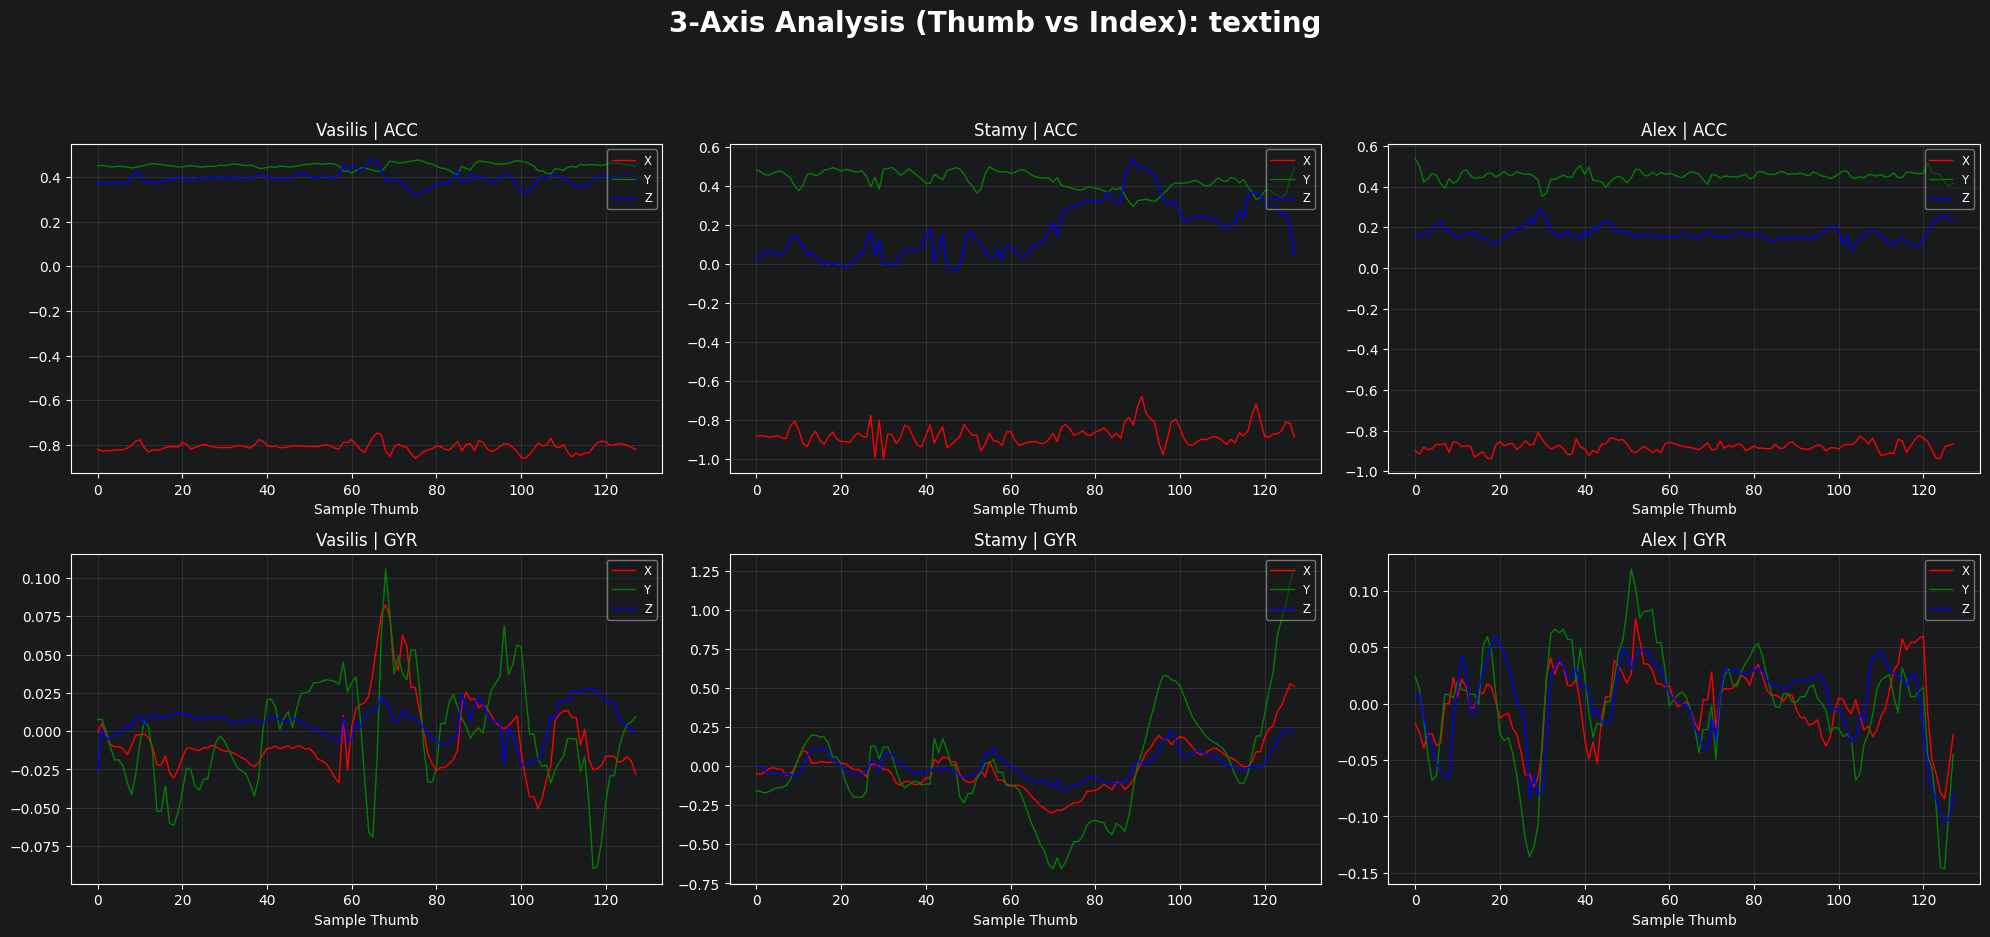

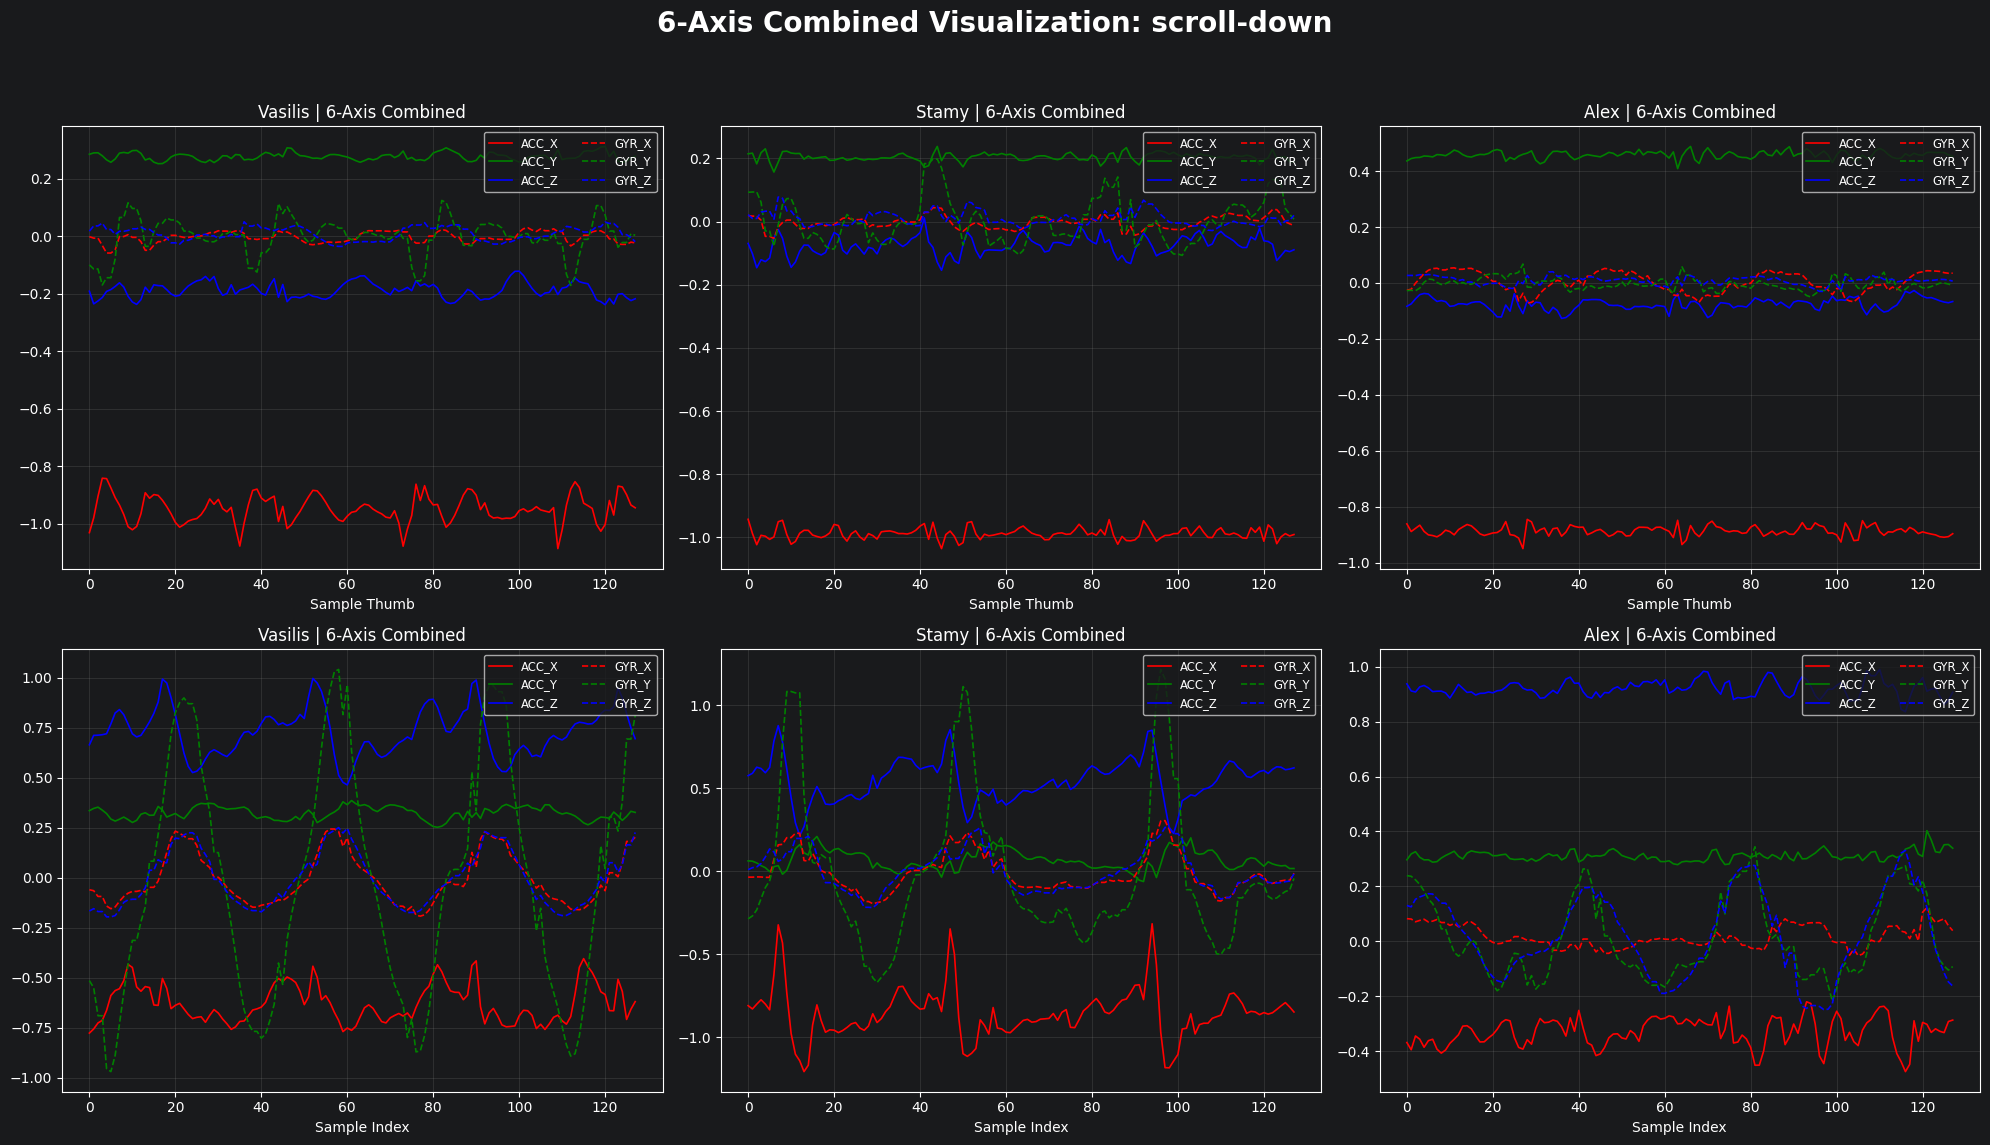

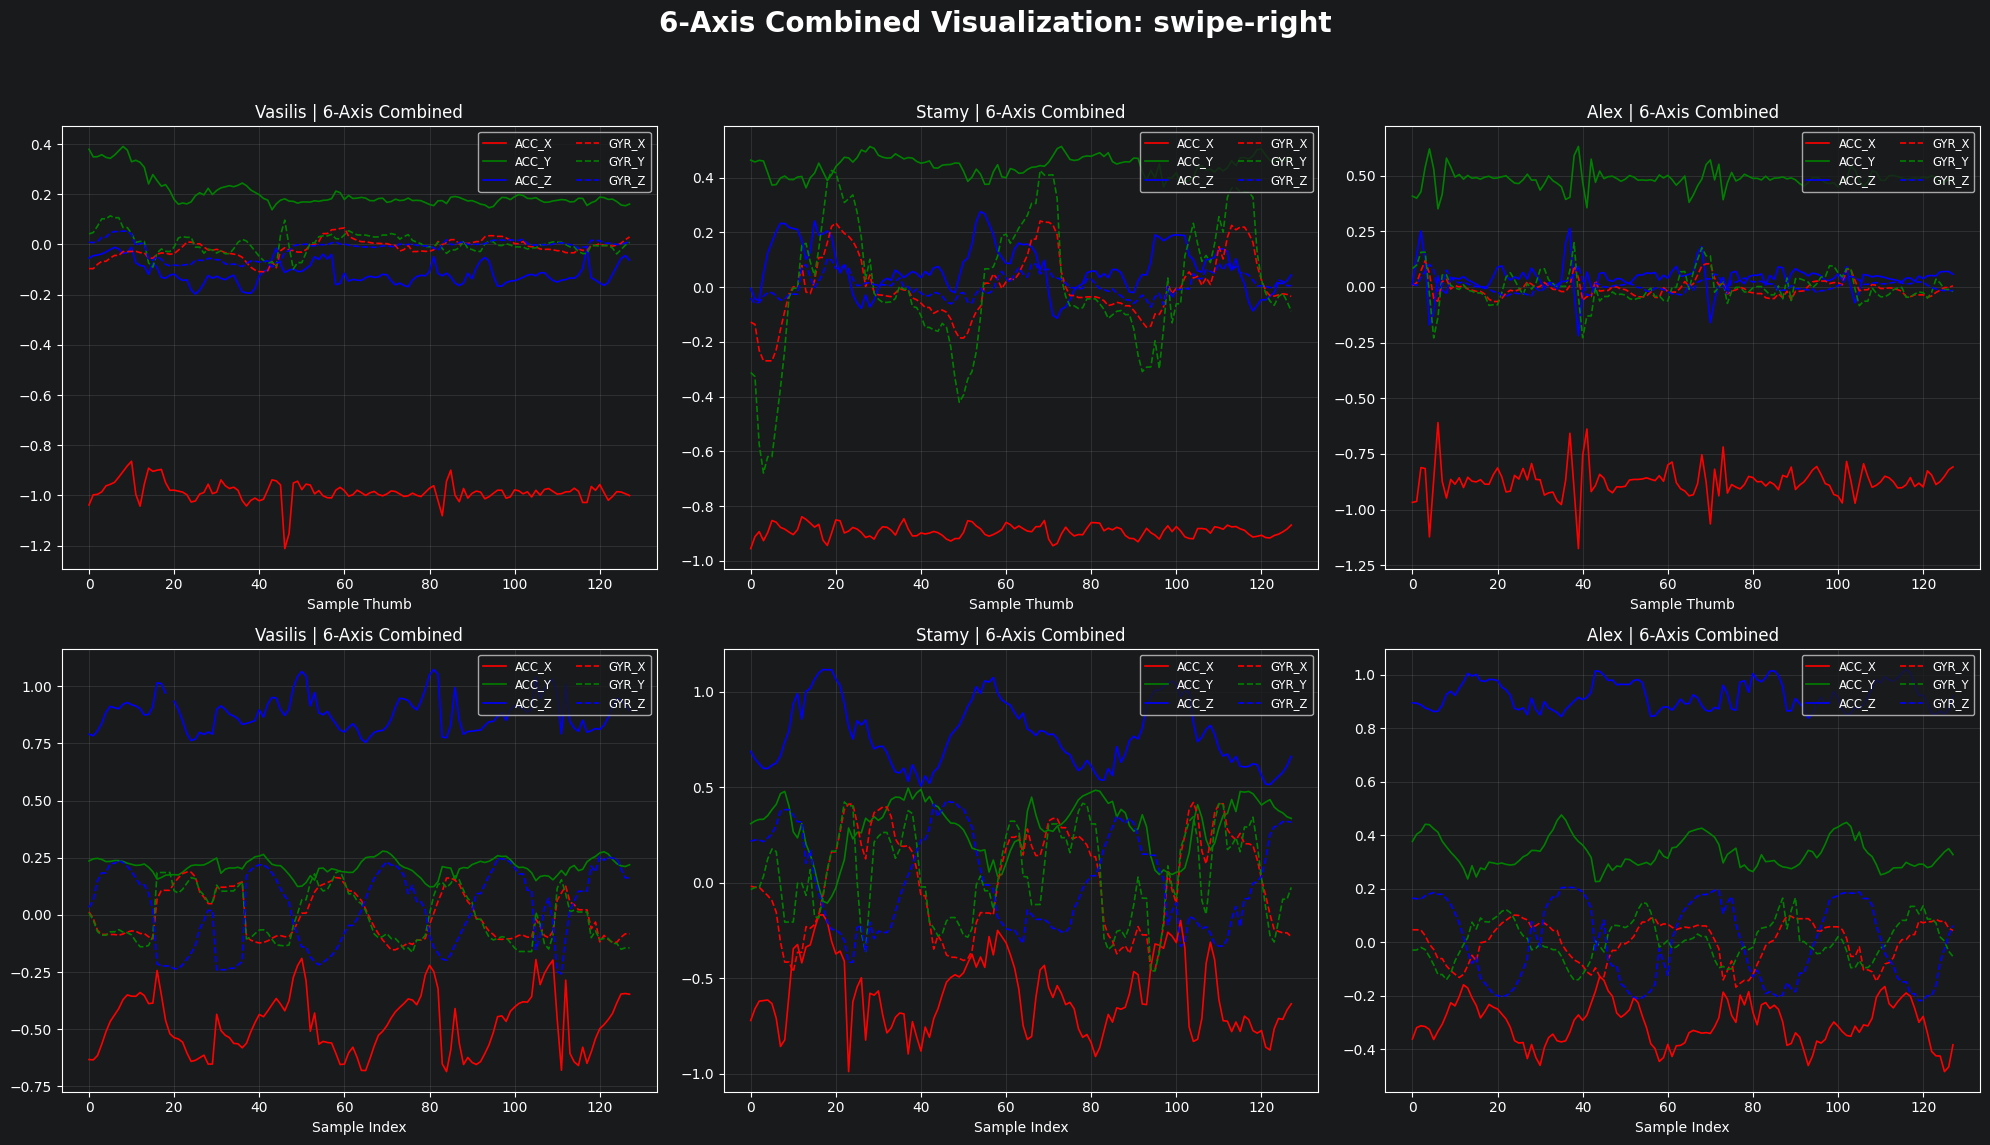

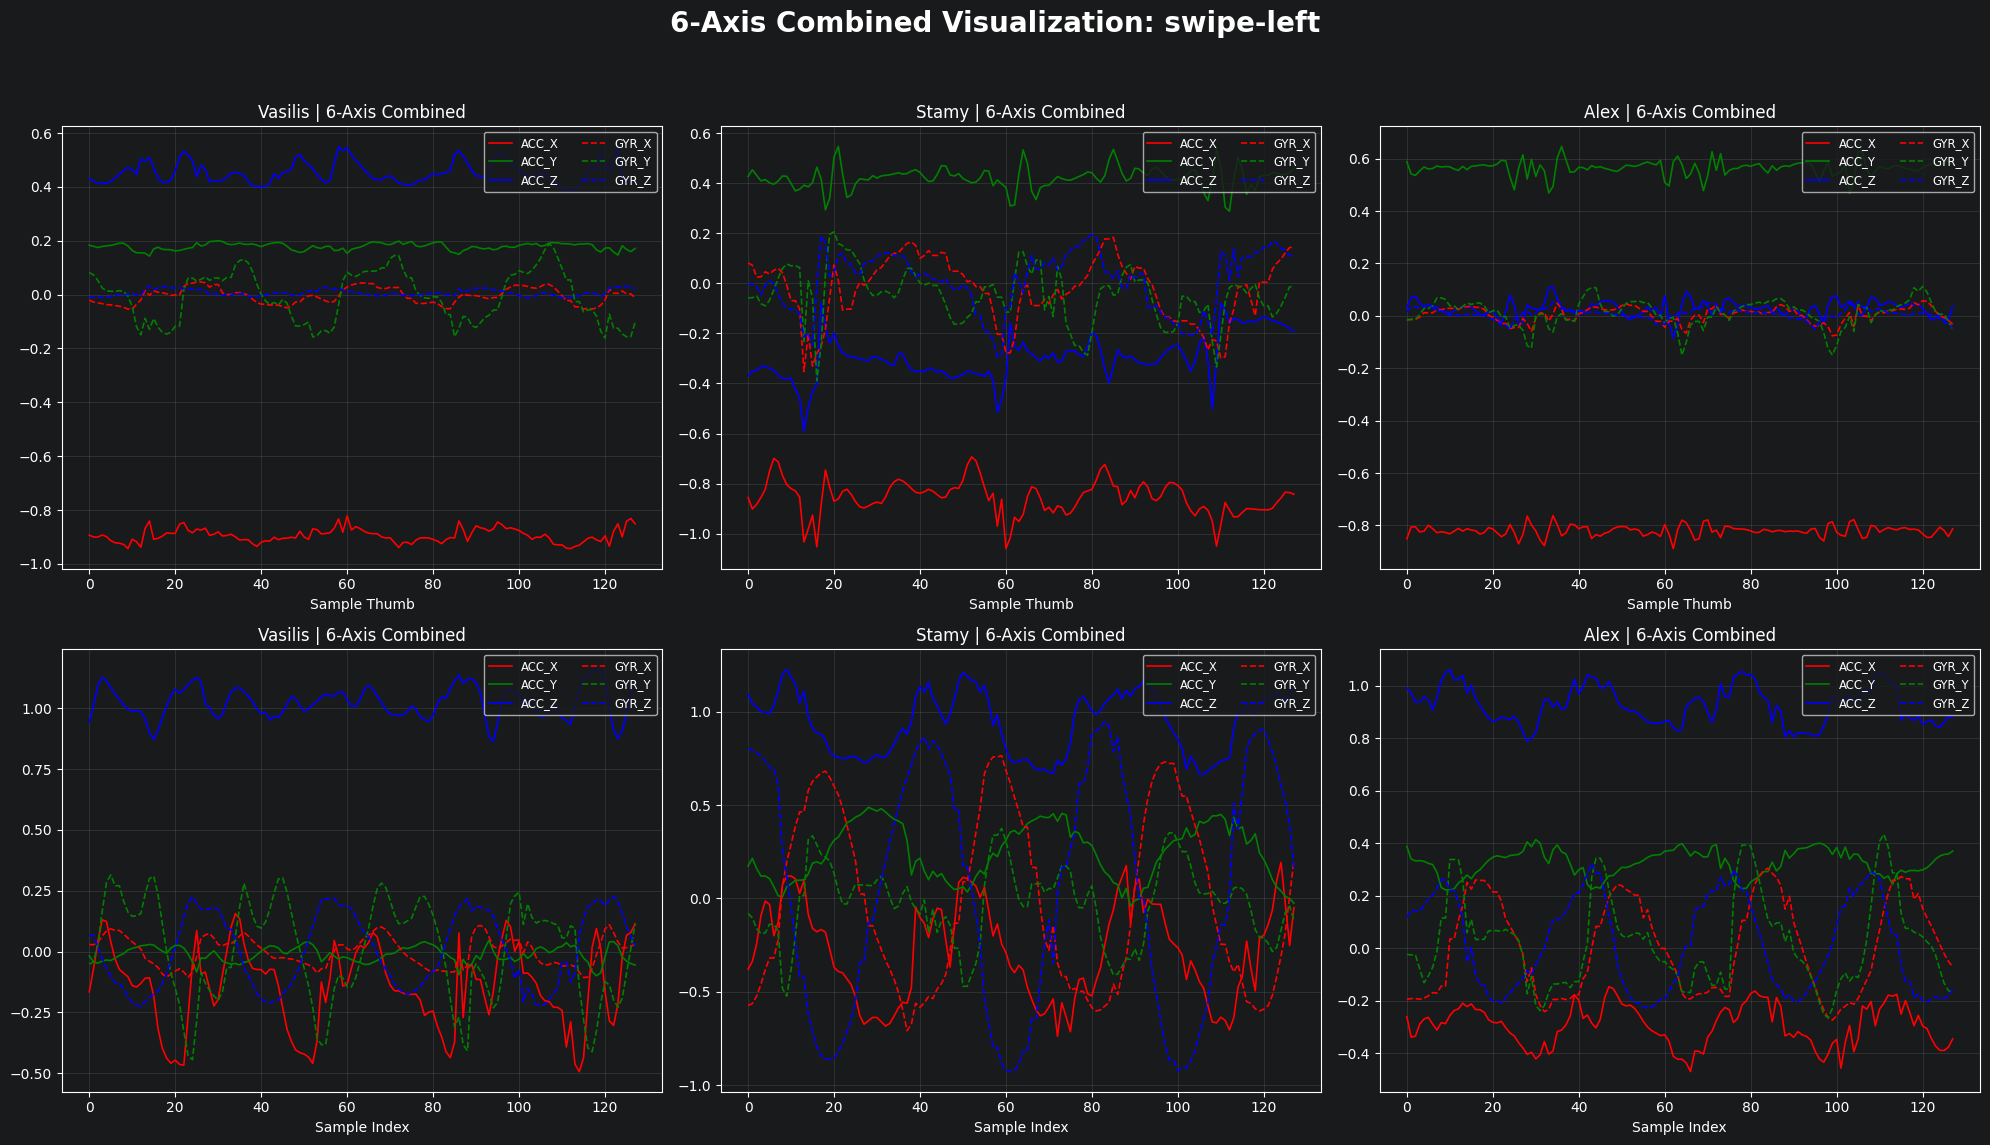

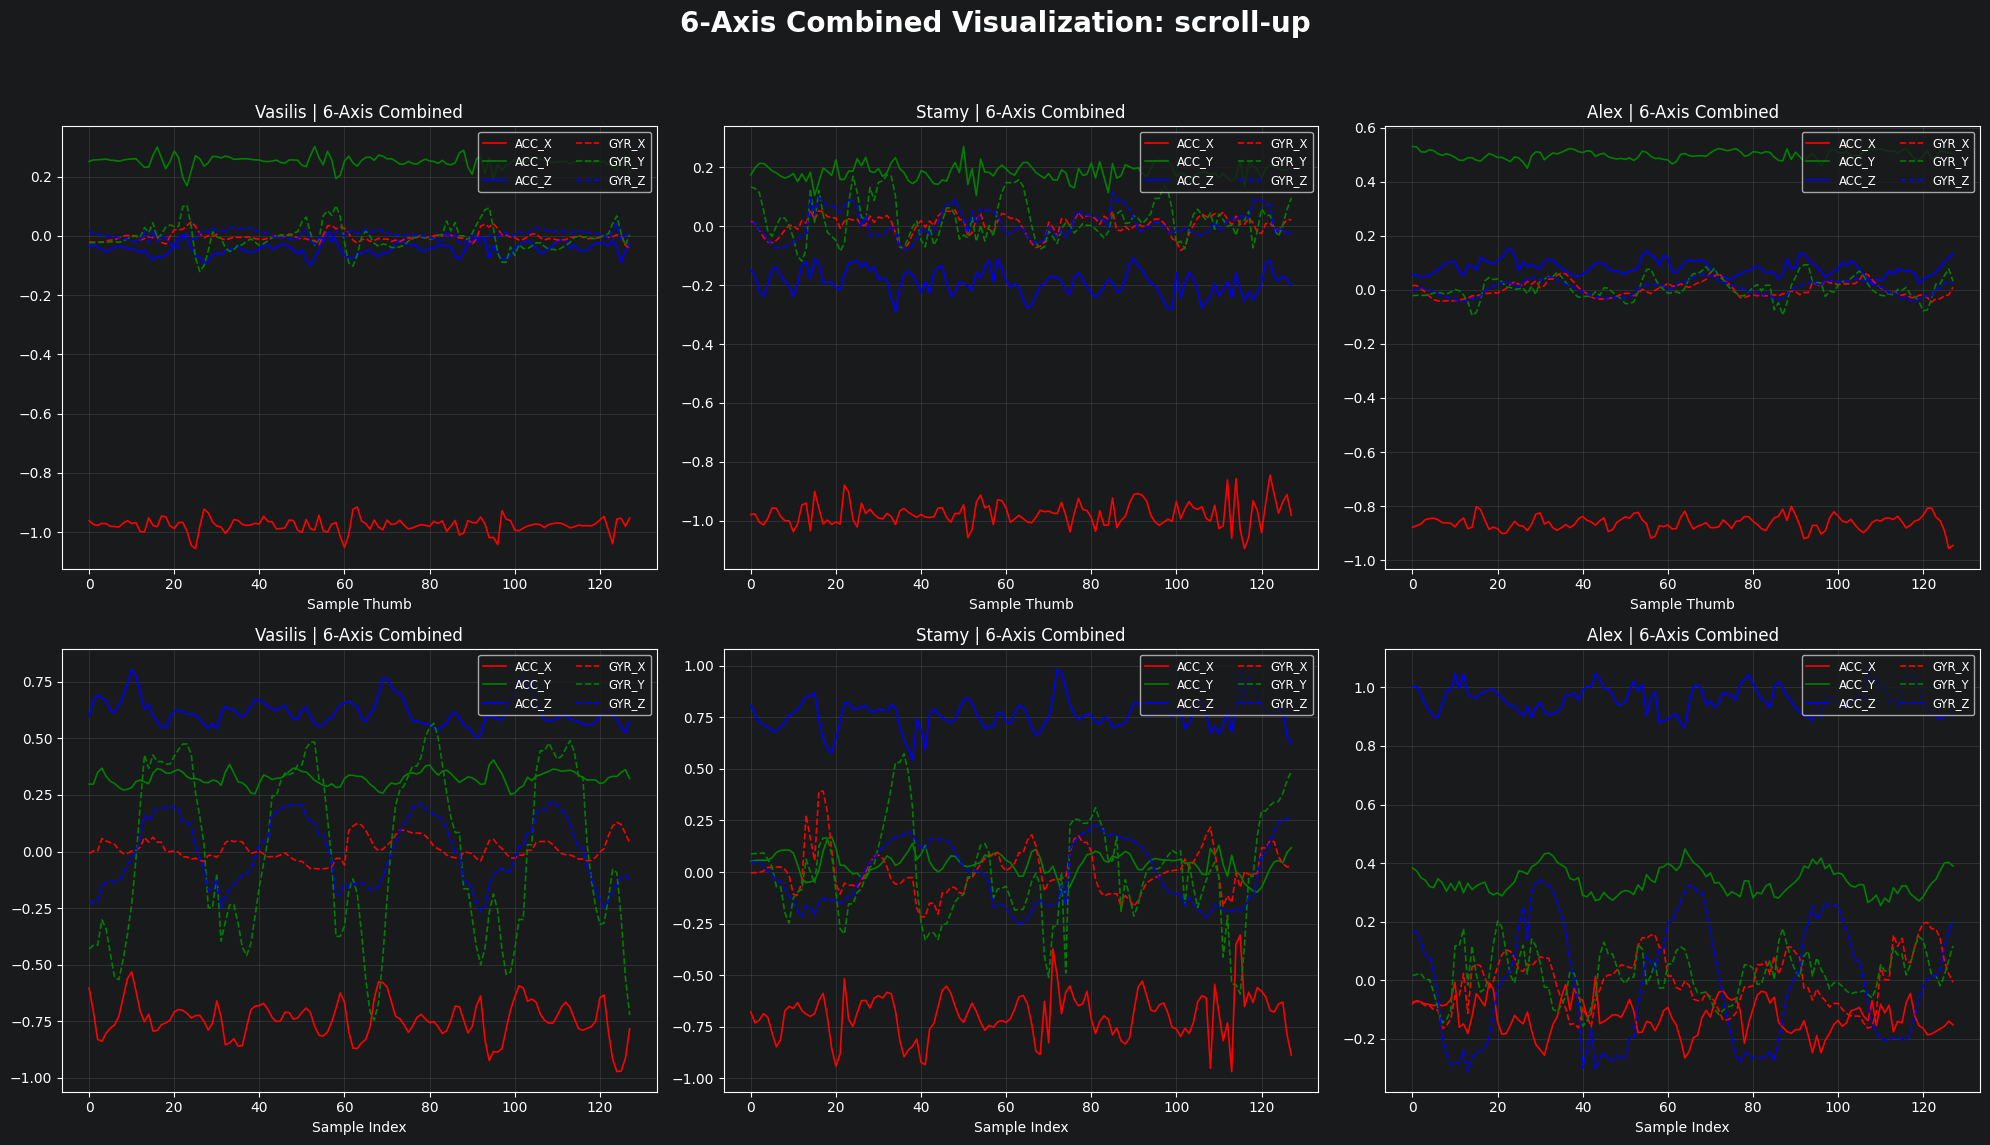

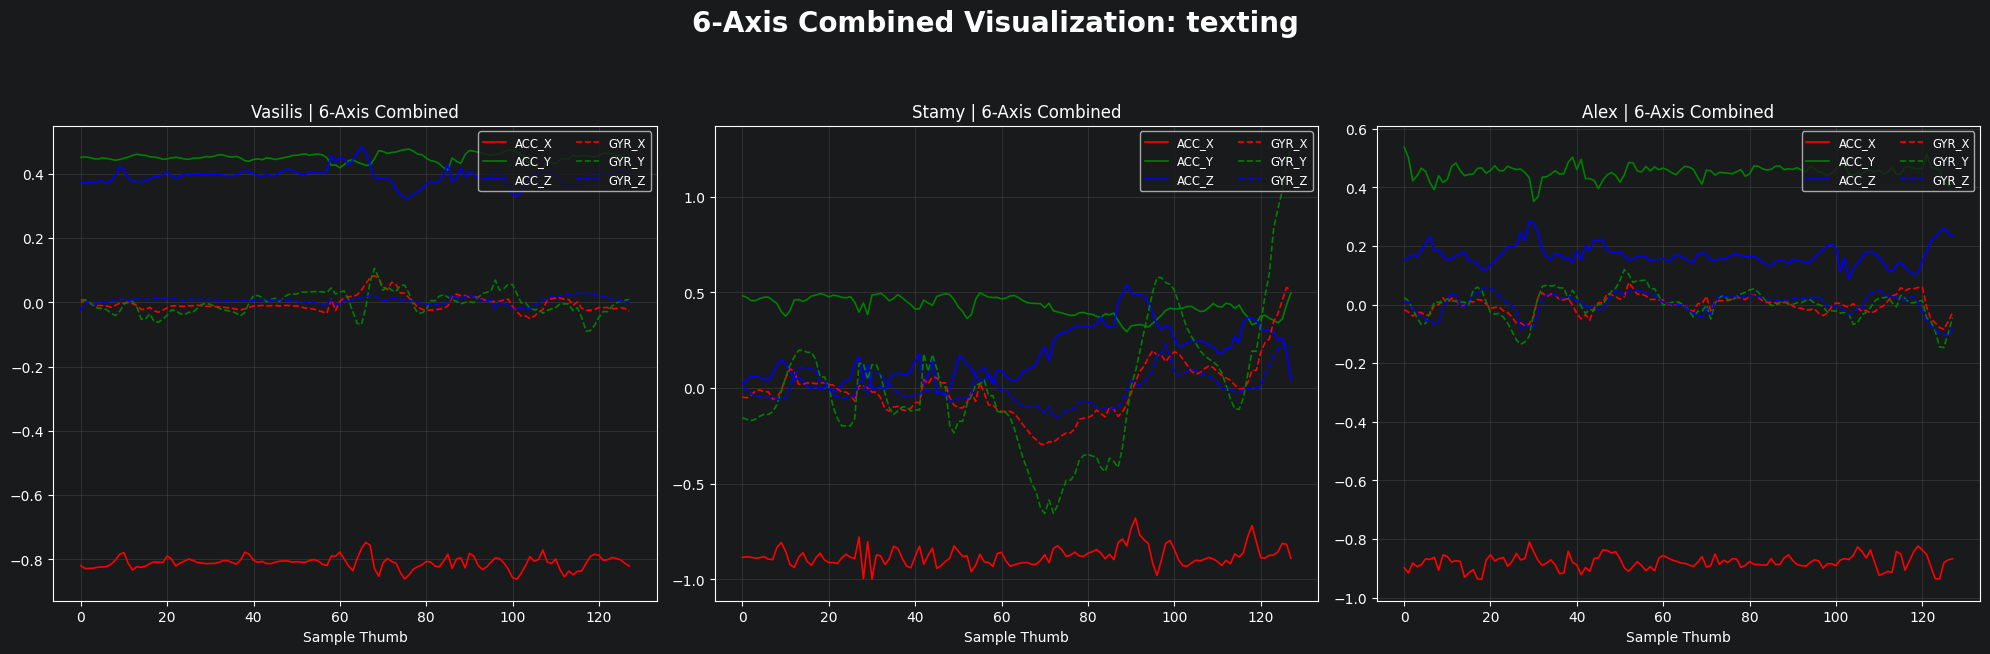

In [5]:
all_users = load_data_for_visualization(pairs)

Plot_3axis(all_users, out_dir=FIGURES_DIR)
Plot_6axis(all_users, out_dir=FIGURES_DIR)

## 3. Load + Merge + Filter

Each pair is loaded, joined on `Epoch` with a 10 ms tolerance, and lowpass-filtered (Butterworth, order 4, fc=10 Hz @ fs=100 Hz). The result is one 6-axis DataFrame per session.


In [6]:
sessions = []
for meta, acc, gyr in pairs:
    merged = merge_acc_gyr(load_acc_csv(acc), load_gyr_csv(gyr))
    df = apply_continuous_filter(merged, order=FILTER_ORDER, wn=FILTER_WN)
    meta = {**meta, "acc_csv": acc.stem, "gyr_csv": gyr.stem}
    sessions.append((df, meta))
print(f"Loaded {len(sessions)} merged sessions")

# Quick sanity on the first filtered dataframe
df0, meta0 = sessions[0]
print(f"First session: {meta0['gesture_id']} / {meta0['finger']} / user={meta0['user']}  shape={df0.shape}")
df0.head()

Loaded 27 merged sessions
First session: scroll-down / index / user=a  shape=(15147, 7)


,Epoch,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,1777373011388,-0.366956,0.306461,0.929578,0.080358,0.239013,0.133912
1,1777373011389,-0.365446,0.307777,0.926737,0.079433,0.234093,0.141068
2,1777373011390,-0.365196,0.307271,0.924104,0.078515,0.224637,0.149839
3,1777373011391,-0.367067,0.305093,0.921593,0.077554,0.209442,0.158654
4,1777373011418,-0.371309,0.302069,0.918973,0.076385,0.187783,0.165560


## 4. Insert into MongoDB

`mongo_connect(reset=True)` clears existing documents in the collection (idempotent re-run) and creates a unique index on `session_id`.

In [7]:
coll = mongo_connect(uri=config["client"], db=config["db"], collection=config["col"], reset=config["reset_collection"])
print(f"Connected to {coll.full_name}")

docs = (build_document(df, meta) for df, meta in sessions)
n_ins = insert_documents(coll, docs)
print(f"Inserted {n_ins} documents")

Connected to IoTSocial.sensor_data
Inserted 27 documents


## 5. Verification

In [8]:
assert coll.count_documents({}) == len(sessions), "Document count mismatch"

# Count per gesture
from collections import Counter
gestures = Counter(d["gesture_id"] for d in coll.find({}, {"gesture_id": 1}))
print("Per gesture:", dict(gestures))

# Inspect one document in MongoDB (without the heavy `data` field)
sample = coll.find_one({}, {"data": 0})
sample

Per gesture: {'scroll-down': 6, 'scroll-up': 6, 'swipe-left': 6, 'swipe-right': 6, 'texting': 3}


{'_id': ObjectId('6a0c30a46f12e6d3cdf9595a'),
 'session_id': 'd3507d5d5e95f18cc5a139b3',
 'gesture_id': 'scroll-down',
 'finger': 'index',
 'typing_style': 'na',
 'hand': 0,
 'sr': 100,
 'sensor': 'AccGyr',
 'primary': 0,
 'spontaneous': 0,
 'user': 'a',
 'datetime': datetime.datetime(2026, 5, 19, 9, 43, 0, 431000)}